In [1]:
% This loads the Octave control-systems "package," which implements the "ss" and "lsim" commands.
pkg load control
pkg load symbolic

In [2]:
maxT = 1000; % maximum simulation time, used for all models (in iterations)
dT = 0.1;    % sample period used by all models (in seconds)

### The nearly constant position model

The 2-d NCP model is
$$\dot{x}\left(t\right)=0_{2\times2}x\left(t\right)+I_2w\left(t\right) $$
$$z\left(t\right)=x\left(t\right)+v\left(t\right)$$

Then, in discrete time

$$x_{k+1} = e^{0\Delta t}x_k+ \left(\int e^{0\sigma} d\sigma\right)Iw_k$$
$$z_{k}=x_k+v_k$$

Then
- $A_d=e^{0 \Delta t}=I$
- $B_d=\int_{0}^{\Delta t}Id\sigma=I\Delta t$


In [3]:
% Define the NCP model
Ancp = eye(2); 
Bwncp = eye(2);
Cncp = eye(2); 
Dncp  = zeros(2);

In [4]:
% Simulate the NCP model
randn("state",0); % Don't change this line since it affects the simulation results that are used in the quiz
wncp = 0.1*randn(2,maxT);
vncp = 0.01*randn(2,maxT);

xncp = zeros(2,maxT); % storage
xncp(:,1)=[0;0];    % initial posn. 
for k=2:maxT     % simulate model
  xncp(:,k)=Ancp*xncp(:,k-1)+Bwncp*wncp(:,k-1);
end
zncp = Cncp*xncp + vncp;


The gnuplot graphics toolkit is not actively maintained and has a number
of limitations that are ulikely to be fixed.  Communication with gnuplot
uses a one-directional pipe and limited information is passed back to the
Octave interpreter so most changes made interactively in the plot window
will not be reflected in the graphics properties managed by Octave.  For
example, if the plot window is closed with a mouse click, Octave will not
be notified and will not update it's internal list of open figure windows.
We recommend using the qt toolkit instead.


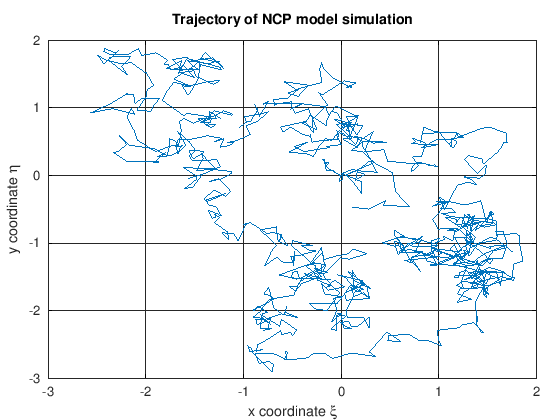

In [5]:
% Plot the simulation output
plot(zncp(1,:),zncp(2,:));
xlabel('x coordinate \xi');
ylabel('y coordinate \eta');
title('Trajectory of NCP model simulation');
grid on

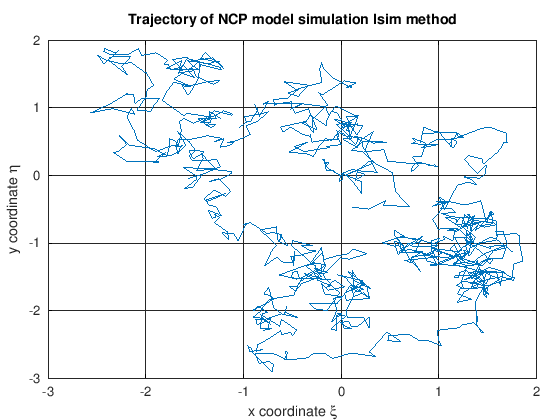

In [6]:
ncp = ss(Ancp,Bwncp,Cncp,Dncp,-1);
zncp = lsim (ncp ,wncp')+vncp';
plot (zncp(: ,1) ,zncp(: ,2) );
xlabel('x coordinate \xi');
ylabel('y coordinate \eta');
title('Trajectory of NCP model simulation lsim method');
grid on

### The nearly constant velocity model

Recall the 2-d continuous-time state equation

$$\dot{x}\left(t\right)=Ax\left(t\right)+Bw\left(t\right) $$

And:
- $A_d=e^{A\Delta t}$
- $B_d =\int_{0}^{\Delta t}e^{A\sigma}Bd\sigma$

In [7]:
A = [0 1 0 0; 0 0 0 0; 0 0 0 1; 0 0 0 0];
B = [0 0; 1 0; 0 0; 0 1];
A, B

A =

   0   1   0   0
   0   0   0   0
   0   0   0   1
   0   0   0   0

B =

   0   0
   1   0
   0   0
   0   1



In [8]:
syms dT sigma
Ancv = expm(A*dT)
Bncv = int(expm (A* sigma ),0 , dT)*B

Symbolic pkg v3.2.2: Python communication link active, SymPy v1.9.
Ancv = (sym 4×4 matrix)

  ⎡1  dT  0  0 ⎤
  ⎢            ⎥
  ⎢0  1   0  0 ⎥
  ⎢            ⎥
  ⎢0  0   1  dT⎥
  ⎢            ⎥
  ⎣0  0   0  1 ⎦

Bncv = (sym 4×2 matrix)

  ⎡  2     ⎤
  ⎢dT      ⎥
  ⎢───   0 ⎥
  ⎢ 2      ⎥
  ⎢        ⎥
  ⎢dT    0 ⎥
  ⎢        ⎥
  ⎢       2⎥
  ⎢     dT ⎥
  ⎢ 0   ───⎥
  ⎢      2 ⎥
  ⎢        ⎥
  ⎣ 0   dT ⎦



In [9]:
% dT_val = sym(0.1, 'f');
dT = sym(0.1, 'f');

Cncv = [1 0 0 0; 0 0 1 0]; 
Dncv = zeros(2);
Ancv = double(eval(Ancv))
Bncv = double(eval(Bncv))

Ancv =

   1.0000   0.1000        0        0
        0   1.0000        0        0
        0        0   1.0000   0.1000
        0        0        0   1.0000

Bncv =

   0.0050        0
   0.1000        0
        0   0.0050
        0   0.1000



In [10]:
randn("state",0); % Don't change this line since it affects the simulation results that are used in the quiz
wncv = 0.1*randn(2,maxT);
vncv = 0.01*randn(2,maxT);

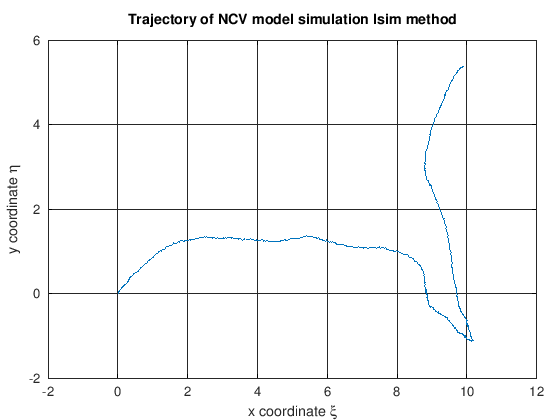

In [11]:
x0 = [ 0 ; 0.1 ; 0 ; 0.1 ] ; % init state

xncv = ss(Ancv,Bncv,Cncv,Dncv,-1);
zncv = lsim(xncv ,wncv',[],x0)+vncv';
plot (zncv(: ,1) ,zncv(: ,2) );
xlabel('x coordinate \xi');
ylabel('y coordinate \eta');
title('Trajectory of NCV model simulation lsim method');
grid on

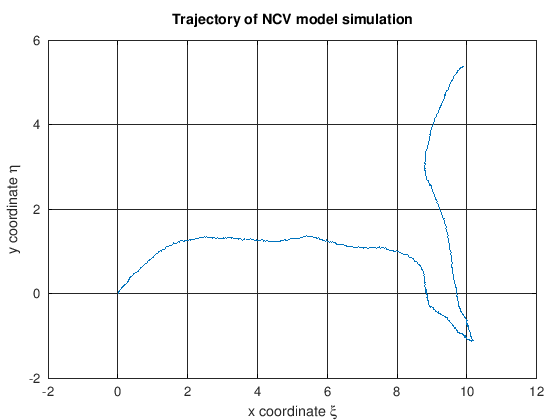

In [12]:
xncv = zeros(4,maxT); % storage
xncv(:,1) = [0;0.1;0;0.1]; % initial position, velocity 
 
for k=2:maxT    % simulate model
  xncv(:,k)=Ancv*xncv(:,k-1)+Bncv*wncv(:,k-1);
end
zncv = Cncv*xncv + vncv;

% Plot the simulation output
plot(zncv(1,:),zncv(2,:));
xlabel('x coordinate \xi');
ylabel('y coordinate \eta');
title('Trajectory of NCV model simulation');
grid on

### Why the empty array [] is used
- Automatic Time Alignment: For a discrete-time system (like your ncv model), lsim knows the sampling interval because you defined it in the ss command. By passing [], you are telling Octave: "Use the $dT$ from the model to match the number of rows in my input $w'$".
- Placeholder Requirement: The lsim function expects a specific order of arguments: lsim(sys, u, t, x0). Since you want to provide an initial state ($x_0$) as the fourth argument, you must provide something for the third argument ($t$) as a placeholder.
- Avoiding Manual Vectors: While you could manually create a time vector (e.g., 0:dT:(maxT-1)*dT), it is redundant for discrete systems and prone to "off-by-one" errors. The empty array is the cleanest way to let the solver handle the timing.


### Breaking down the lsim call
The expression `zncv = lsim(xncv, wncv', [], x0) + vncv'` performs the following:
- `xncv`: The discrete-time state-space model.
- `wncv'`: The input signal (transposed so time is the vertical dimension).
- `[]`: The time placeholder, allowing Octave to auto-generate the time steps.
- `x0`: The initial conditions for your four states.+ vncv': After the simulation completes, the measurement noise is added to the output to simulate real-world sensor data.